A small, read-only plotting notebook for shock geometry and measurements.

1. Choose an event from `Shocks/Shock Params.json` with the global dropdown and edit `SAT_BLOCKLIST` if needed.
2. For each figure, run its data-prep cell and then its plot cell. Each prep cell reads the current dropdown value, so there is no hidden widget callback state.
3. The kinematic-normal panel reads `Shocks/Kinematic Shock Normals (Wolfram).json`; it does not calculate or export normals.


In [68]:
import json
from pathlib import Path

import ipywidgets as widgets
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import patches, pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["figure.dpi"] = 180


In [82]:
# Global configuration
DATA_DIR = Path("Data")
SHOCK_PARAMS_PATH = Path("Shocks/Shock Params.json")
KINEMATIC_NORMALS_PATH = Path("Shocks/Kinematic Shock Normals (Wolfram).json")

# These spacecraft are excluded from every plot and validation table.
SAT_BLOCKLIST = {"stereo", "themis_c"}
PLANAR_FIT_SATELLITES = {"ace", "wind", "dscovr", "themis_b"}
SPHERICAL_FIT_SATELLITES = PLANAR_FIT_SATELLITES | {"mms1"}

OVERVIEW_LINEWIDTH = 1.4
LOCATION_X_LIMITS = (-150, 400)
LOCATION_YZ_LIMITS = (-200, 300)
OVERVIEW_HALF_WINDOW = pd.Timedelta(minutes=40)

# MHD sweep configuration: [start, end] minutes relative to each satellite shock time.
MHD_SATELLITE = "dscovr"
MHD_UPSTREAM_WINDOWS = list(map(lambda x: (x - 5, x), range(-10,0,2)))
MHD_UPSTREAM_WINDOWS = list(map(lambda x: (x, x + 5), range(0,10,2)))
# MHD_UPSTREAM_WINDOWS = [(-8, -5), (-7, -4), (-6, -3), (-5, -2), (-4, -1)]
# MHD_DOWNSTREAM_WINDOWS = [(1, 4), (2, 5), (3, 6), (4, 7)]
MHD_METHODS = ("MC", "MX1", "MX2", "MX3", "VC")

# Each selector maps to one row in the compact Section 3 table.
MHD_TABLE_ROWS = (
    ("All satellites, all methods", "All satellites", "All methods"),
    ("All satellites, MX3", "All satellites", "MX3"),
    ("ACE, MX3", "ace", "MX3"),
    ("DSCOVR, MX3", "dscovr", "MX3"),
)

SHOCK_PARAMETERS = json.loads(SHOCK_PARAMS_PATH.read_text())
KINEMATIC_NORMALS = json.loads(KINEMATIC_NORMALS_PATH.read_text())
EVENT_OPTIONS = sorted(SHOCK_PARAMETERS)

EVENT = "2024-05-10 16-36-00"
assert EVENT in EVENT_OPTIONS
EVENT_PICKER = widgets.Dropdown(options=EVENT_OPTIONS, value=EVENT, description="Event:")


## Date Selection

In [70]:
display(EVENT_PICKER)


Dropdown(description='Event:', index=7, options=('2021-11-03 19-32-00', '2022-01-16 19-09-00', '2022-11-24 19-…

## Shared readers and small utilities

These utilities are shared by more than one prep cell. Plot-specific code stays in its own plot cell below.


In [71]:
R_E_KM = 6378.0
POSITION_COLUMN_SETS = (
    ("X_GSE", "Y_GSE", "Z_GSE"),
    ("x_gse", "y_gse", "z_gse"),
    ("GSE_x", "GSE_y", "GSE_z"),
    ("X", "Y", "Z"),
    ("x", "y", "z"),
)
FIELD_VECTOR_COLUMN_SETS = {
    "B": (("B_X_GSE", "B_Y_GSE", "B_Z_GSE"), ("B_X_HGE", "B_Y_HGE", "B_Z_HGE"), ("B_x", "B_y", "B_z")),
    "V": (("V_X_GSE", "V_Y_GSE", "V_Z_GSE"), ("V_X_HGE", "V_Y_HGE", "V_Z_HGE"), ("v_x", "v_y", "v_z"), ("Proton_VX_moment", "Proton_VY_moment", "Proton_VZ_moment")),
}
FIELD_SCALAR_COLUMNS = {"B": ("B",), "V": ("V", "v", "Proton_V_moment")}


def canonical_satellite(name):
    satellite = str(name).lower().replace("-", "_").replace(" ", "_")
    return "mms1" if satellite in {"mms1", "mms_1"} else satellite


def event_time_for_frame(value, frame):
    timestamp = pd.Timestamp(value)
    if frame.index.tz is not None:
        return timestamp.tz_localize(frame.index.tz) if timestamp.tz is None else timestamp.tz_convert(frame.index.tz)
    return timestamp.tz_localize(None) if timestamp.tz is not None else timestamp


def load_event(event):
    frames = {}
    event_path = DATA_DIR / event
    for parquet_path in sorted(event_path.glob("*.parquet")) if event_path.is_dir() else []:
        satellite = canonical_satellite(parquet_path.stem)
        frame = pd.read_parquet(parquet_path)
        if not isinstance(frame.index, pd.DatetimeIndex):
            time_column = next(column for column in ("time", "Time", "datetime", "date", "timestamp", "Timestamp") if column in frame.columns)
            frame = frame.set_index(time_column)
        frame.index = pd.to_datetime(frame.index)
        frame = frame.sort_index()
        frames[satellite] = frame.loc[~frame.index.duplicated(keep="first")].copy()

    parameters = {
        canonical_satellite(satellite): {**values, "t0": pd.Timestamp(values["t0"])}
        for satellite, values in SHOCK_PARAMETERS[event].items()
        if isinstance(values, dict) and "t0" in values
    }
    satellites = [
        satellite
        for satellite in sorted(frames)
        if satellite in parameters and satellite not in SAT_BLOCKLIST
    ]
    return frames, parameters, KINEMATIC_NORMALS.get(event, {}), satellites


def utc_timestamp(value):
    timestamp = pd.Timestamp(value)
    return timestamp.tz_localize("UTC") if timestamp.tz is None else timestamp.tz_convert("UTC")


def event_satellites(parameters):
    return sorted(
        (satellite for satellite in parameters if satellite not in SAT_BLOCKLIST),
        key=lambda satellite: utc_timestamp(parameters[satellite]["t0"]),
    )


def stored_position(parameters, satellite):
    record = parameters[satellite].get("position")
    if not isinstance(record, dict) or record.get("frame") != "GSE" or record.get("units") != "R_E":
        return None
    coordinates = np.asarray([record.get(axis) for axis in "xyz"], dtype=float)
    return coordinates if np.isfinite(coordinates).all() else None


def position_at_event(frame, t0, satellite):
    for columns in POSITION_COLUMN_SETS:
        if all(column in frame.columns for column in columns):
            positions = frame.loc[:, list(columns)].apply(pd.to_numeric, errors="coerce")
            break
    else:
        return None

    position_time = event_time_for_frame(t0, frame)
    nearest_row = positions.iloc[positions.index.get_indexer([position_time], method="nearest")[0]]
    if nearest_row.isna().any():
        valid_positions = positions.dropna(how="any")
        if valid_positions.empty:
            return None
        nearest_row = valid_positions.iloc[valid_positions.index.get_indexer([position_time], method="nearest")[0]]

    coordinates = nearest_row.to_numpy(dtype=float)
    if canonical_satellite(satellite) != "wind" and np.max(np.abs(coordinates)) >= 1000:
        coordinates = coordinates / R_E_KM
    return coordinates


def fit_record(event_fit, model, expected_satellites):
    model_fits = event_fit.get(model, {})
    matches = [
        fit
        for fit in model_fits.values()
        if isinstance(fit, dict) and set(map(canonical_satellite, fit.get("satellites", []))) == expected_satellites
    ]
    assert len(matches) == 1, f"Expected one {model} fit using {sorted(expected_satellites)}; found {len(matches)}"
    return matches[0]


def shock_velocity(fit):
    velocity = np.asarray(fit["shock_velocity_gse_km_s"], dtype=float)
    assert velocity.shape == (3,) and np.isfinite(velocity).all()
    return velocity


def local_surface_normal(fit, position_re, crossing_time):
    surface = fit["surface"]
    velocity = shock_velocity(fit)
    if surface["type"] == "plane":
        normal = np.asarray(surface["normal_gse"], dtype=float)
    else:
        reference_center = np.asarray(surface["center_at_reference_re"], dtype=float)
        elapsed_seconds = (utc_timestamp(crossing_time) - utc_timestamp(fit["reference_time"])).total_seconds()
        center_at_crossing = reference_center + velocity * elapsed_seconds / R_E_KM
        normal = np.asarray(position_re, dtype=float) - center_at_crossing
    normal = normal / np.linalg.norm(normal)
    return -normal if np.dot(velocity, normal) < 0 else normal


def downstream_velocity(parameters, satellite):
    record = parameters[satellite].get("velocity_downstream")
    if not isinstance(record, dict) or record.get("frame") != "GSE" or record.get("units") != "km/s":
        return None
    velocity = np.asarray([record.get(axis) for axis in "xyz"], dtype=float)
    return velocity if np.isfinite(velocity).all() else None


def field_vector_columns(frame, field):
    for columns in FIELD_VECTOR_COLUMN_SETS[field]:
        if all(column in frame.columns for column in columns):
            return columns
    raise KeyError(f"No {field}-vector columns found")


def field_magnitude(frame, field):
    for column in FIELD_SCALAR_COLUMNS[field]:
        if column in frame.columns:
            return pd.to_numeric(frame[column], errors="coerce")
    for columns in FIELD_VECTOR_COLUMN_SETS[field]:
        if all(column in frame.columns for column in columns):
            vectors = frame.loc[:, list(columns)].apply(pd.to_numeric, errors="coerce")
            return np.sqrt((vectors**2).sum(axis=1))
    return None


def normal_angles(normal):
    unit_normal = np.asarray(normal, dtype=float) / np.linalg.norm(normal)
    theta = np.degrees(np.pi / 2 + np.arccos(np.clip(unit_normal[2], -1, 1)))
    phi = np.degrees(np.pi - np.arcsin(np.clip(unit_normal[1] / np.hypot(unit_normal[0], unit_normal[1]), -1, 1)))
    return theta, phi


def satellite_label(satellite):
    satellite = canonical_satellite(satellite)
    return {"themis_b": "THEMIS-B", "themis_c": "THEMIS-C", "wind": "Wind"}.get(satellite, satellite.upper())


## 1. Satellite locations in the XY and XZ planes


In [72]:
# Data prep: catalogue positions at each satellite's stored shock time
EVENT = EVENT_PICKER.value
location_frames, location_params, _, _ = load_event(EVENT)

location_rows = []
for satellite in event_satellites(location_params):
    coordinates = stored_position(location_params, satellite)
    if coordinates is None and satellite in location_frames:
        coordinates = position_at_event(location_frames[satellite], location_params[satellite]["t0"], satellite)
    if coordinates is not None:
        location_rows.append({"satellite": satellite, "x": coordinates[0], "y": coordinates[1], "z": coordinates[2]})

location_data = pd.DataFrame(location_rows)
assert not location_data.empty, f"No plotted satellite locations for {EVENT}"
location_data = location_data.set_index("satellite")
display(location_data)


,x,y,z
satellite,,,
dscovr,244.548418,-28.303406,20.415506
ace,223.818125,2.981812,22.363750
wind,215.565506,100.757660,-1.021581
themis_b,46.396865,33.532369,4.729635
mms1,11.589013,-21.908406,-6.586670


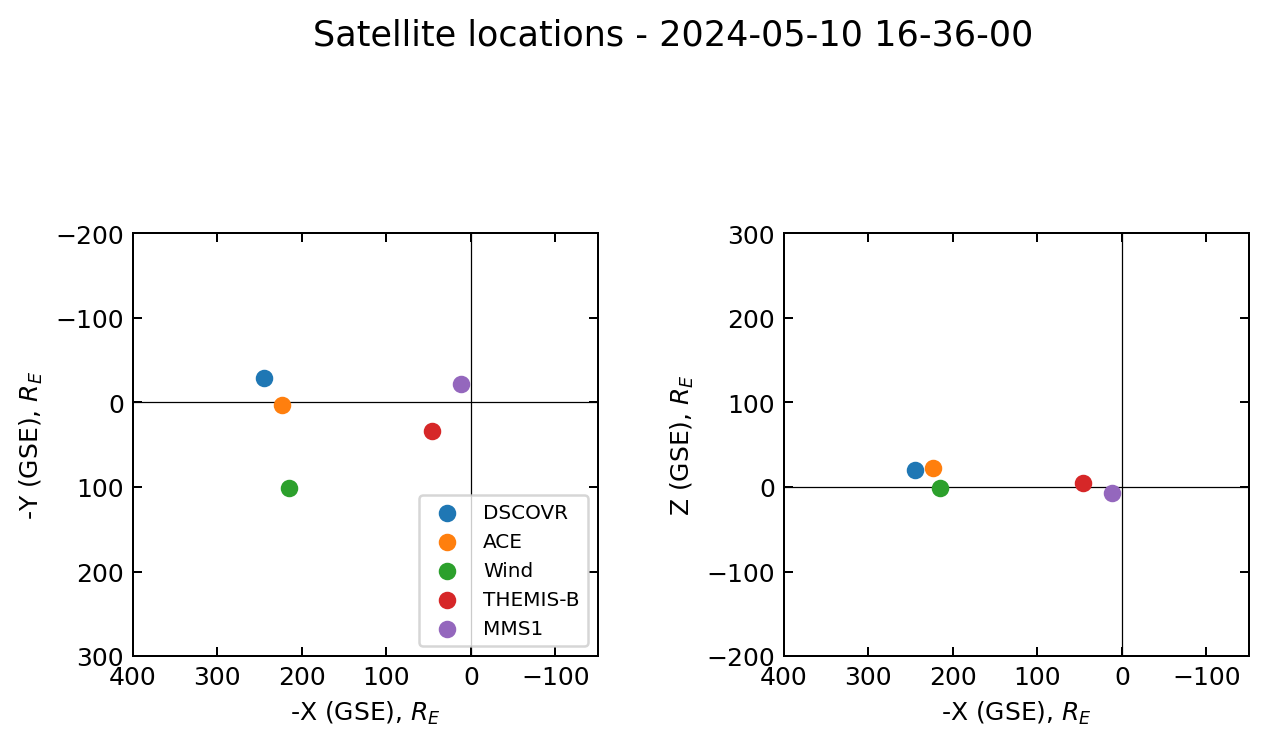

In [73]:
# Plot: satellite locations only
fig, (ax_xy, ax_xz) = plt.subplots(ncols=2, figsize=(8, 5), gridspec_kw={"wspace": 0.4})

for color_index, (satellite, row) in enumerate(location_data.iterrows()):
    color = f"C{color_index}"
    ax_xy.scatter(row["x"], row["y"], color=color, label=satellite_label(satellite), zorder=3)
    ax_xz.scatter(row["x"], row["z"], color=color, zorder=3)

for axis in (ax_xy, ax_xz):
    axis.axhline(0, color="black", linewidth=0.5)
    axis.axvline(0, color="black", linewidth=0.5)
    axis.set_aspect("equal")
    axis.tick_params(which="both", direction="in", top=True, right=True)

ax_xy.set(xlim=LOCATION_X_LIMITS, ylim=LOCATION_YZ_LIMITS, xlabel=r"-X (GSE), $R_E$", ylabel=r"-Y (GSE), $R_E$")
ax_xz.set(xlim=LOCATION_X_LIMITS, ylim=LOCATION_YZ_LIMITS, xlabel=r"-X (GSE), $R_E$", ylabel=r"Z (GSE), $R_E$")
ax_xy.invert_xaxis()
ax_xy.invert_yaxis()
ax_xz.invert_xaxis()
ax_xy.legend(loc="lower right", fontsize=8)
fig.suptitle(f"Satellite locations - {EVENT}", fontsize=14)
fig.subplots_adjust(top=0.9)
plt.show()


## 2. Wolfram spherical and planar kinematic shock surfaces

This panel reads the selected satellite-keyed records from the Wolfram JSON. It draws the fitted plane and reference-time sphere, plus the sphere's local normal at each catalogue crossing position. MHD normals are intentionally absent.


In [74]:
# Data prep: selected Wolfram fits and catalogue crossing positions
EVENT = EVENT_PICKER.value
normal_frames, normal_params, normal_fit, _ = load_event(EVENT)
planar_fit = fit_record(normal_fit, "planar", PLANAR_FIT_SATELLITES)
spherical_fit = fit_record(normal_fit, "spherical", SPHERICAL_FIT_SATELLITES)

normal_rows = []
for satellite in event_satellites(normal_params):
    coordinates = stored_position(normal_params, satellite)
    if coordinates is None and satellite in normal_frames:
        coordinates = position_at_event(normal_frames[satellite], normal_params[satellite]["t0"], satellite)
    if coordinates is not None:
        normal_rows.append({"satellite": satellite, "x": coordinates[0], "y": coordinates[1], "z": coordinates[2]})

normal_positions = pd.DataFrame(normal_rows)
assert not normal_positions.empty, f"No plotted satellite locations for {EVENT}"
normal_positions = normal_positions.set_index("satellite")

planar_surface = planar_fit["surface"]
planar_normal = np.asarray(planar_surface["normal_gse"], dtype=float)
planar_offset = float(planar_surface["offset_re"])
sphere_surface = spherical_fit["surface"]
sphere_center = np.asarray(sphere_surface["center_at_reference_re"], dtype=float)
sphere_radius = float(sphere_surface["radius_re"])
spherical_normals = {
    satellite: local_surface_normal(
        spherical_fit,
        row[["x", "y", "z"]].to_numpy(dtype=float),
        normal_params[satellite]["t0"],
    )
    for satellite, row in normal_positions.iterrows()
}
display(normal_positions)


,x,y,z
satellite,,,
dscovr,244.548418,-28.303406,20.415506
ace,223.818125,2.981812,22.363750
wind,215.565506,100.757660,-1.021581
themis_b,46.396865,33.532369,4.729635
mms1,11.589013,-21.908406,-6.586670


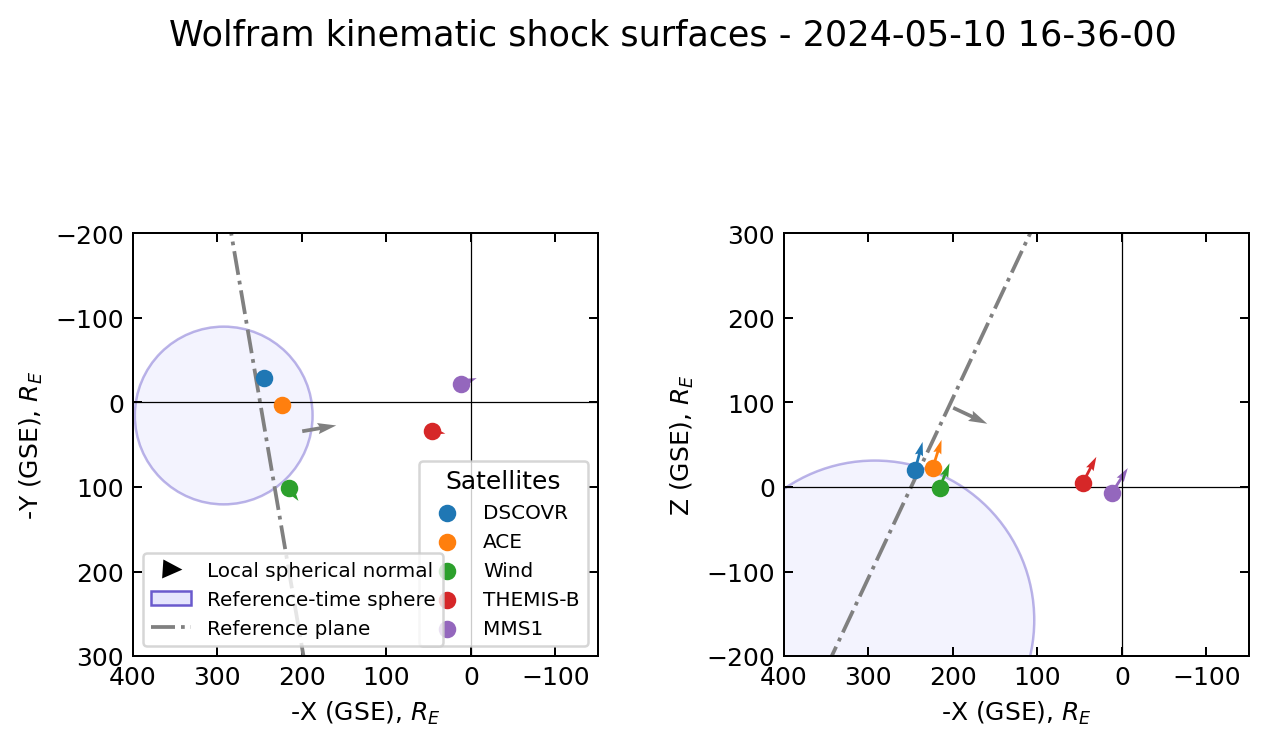

In [75]:
# Plot: Wolfram spherical and planar shock surfaces (no MHD normals)
fig, (ax_xy, ax_xz) = plt.subplots(ncols=2, figsize=(8, 5), gridspec_kw={"wspace": 0.4})

if sphere_radius**2 > sphere_center[2] ** 2:
    ax_xy.add_patch(patches.Circle((sphere_center[0], sphere_center[1]), np.sqrt(sphere_radius**2 - sphere_center[2] ** 2), facecolor="#e5e5fd", edgecolor="slateblue", alpha=0.45, zorder=0))
if sphere_radius**2 > sphere_center[1] ** 2:
    ax_xz.add_patch(patches.Circle((sphere_center[0], sphere_center[2]), np.sqrt(sphere_radius**2 - sphere_center[1] ** 2), facecolor="#e5e5fd", edgecolor="slateblue", alpha=0.45, zorder=0))

for color_index, (satellite, row) in enumerate(normal_positions.iterrows()):
    color = f"C{color_index}"
    ax_xy.scatter(row["x"], row["y"], color=color, label=satellite_label(satellite), zorder=3)
    ax_xz.scatter(row["x"], row["z"], color=color, zorder=3)

    normal = spherical_normals[satellite]
    ax_xy.quiver(row["x"], row["y"], 35 * normal[0], 35 * normal[1], color=color, angles="xy", scale_units="xy", scale=1, width=0.006, zorder=2)
    ax_xz.quiver(row["x"], row["z"], 35 * normal[0], 35 * normal[2], color=color, angles="xy", scale_units="xy", scale=1, width=0.006, zorder=2)

x_values = np.linspace(*LOCATION_X_LIMITS, 400)
if abs(planar_normal[1]) > 1e-12:
    y_values = (planar_offset - planar_normal[0] * x_values) / planar_normal[1]
    ax_xy.plot(x_values, y_values, "-.", color="gray")
if abs(planar_normal[2]) > 1e-12:
    z_values = (planar_offset - planar_normal[0] * x_values) / planar_normal[2]
    ax_xz.plot(x_values, z_values, "-.", color="gray")

plane_anchor = planar_offset * planar_normal
ax_xy.quiver(plane_anchor[0], plane_anchor[1], 45 * planar_normal[0], 45 * planar_normal[1], color="gray", angles="xy", scale_units="xy", scale=1, width=0.008, zorder=2)
ax_xz.quiver(plane_anchor[0], plane_anchor[2], 45 * planar_normal[0], 45 * planar_normal[2], color="gray", angles="xy", scale_units="xy", scale=1, width=0.008, zorder=2)

for axis in (ax_xy, ax_xz):
    axis.axhline(0, color="black", linewidth=0.5)
    axis.axvline(0, color="black", linewidth=0.5)
    axis.set_aspect("equal")
    axis.tick_params(which="both", direction="in", top=True, right=True)

ax_xy.set(xlim=LOCATION_X_LIMITS, ylim=LOCATION_YZ_LIMITS, xlabel=r"-X (GSE), $R_E$", ylabel=r"-Y (GSE), $R_E$")
ax_xz.set(xlim=LOCATION_X_LIMITS, ylim=LOCATION_YZ_LIMITS, xlabel=r"-X (GSE), $R_E$", ylabel=r"Z (GSE), $R_E$")
ax_xy.invert_xaxis()
ax_xy.invert_yaxis()
ax_xz.invert_xaxis()

satellite_legend = ax_xy.legend(loc="lower right", fontsize=8, title="Satellites")
ax_xy.legend(handles=[
    Line2D([0], [0], marker=">", linestyle="none", color="black", label="Local spherical normal"),
    patches.Patch(facecolor="#e5e5fd", edgecolor="slateblue", label="Reference-time sphere"),
    Line2D([0], [0], linestyle="-.", color="gray", label="Reference plane"),
], loc="lower left", fontsize=8)
ax_xy.add_artist(satellite_legend)
fig.suptitle(f"Wolfram kinematic shock surfaces - {EVENT}", fontsize=14)
fig.subplots_adjust(top=0.9)
plt.show()


### Speed validation along each local shock normal

For every non-blocklisted catalogue satellite, this compares the stored shock-velocity vector with the stored downstream GSE plasma velocity after projecting both onto the same local normal. Each normal is oriented so the shock projection is non-negative. Missing downstream vectors remain visible as unavailable rows.


In [76]:
# Validation: shock speed versus downstream flow along the same local normal
EVENT = EVENT_PICKER.value
_, validation_params, validation_fit, _ = load_event(EVENT)
validation_models = {
    "planar": fit_record(validation_fit, "planar", PLANAR_FIT_SATELLITES),
    "spherical": fit_record(validation_fit, "spherical", SPHERICAL_FIT_SATELLITES),
}

validation_rows = []
for model_name, fit in validation_models.items():
    velocity = shock_velocity(fit)
    for satellite in event_satellites(validation_params):
        position = stored_position(validation_params, satellite)
        downstream = downstream_velocity(validation_params, satellite)
        if position is None:
            validation_rows.append({
                "model": model_name,
                "satellite": satellite_label(satellite),
                "shock_normal_km_s": np.nan,
                "downstream_normal_km_s": np.nan,
                "slower_than_downstream": pd.NA,
                "status": "missing position",
            })
            continue
        normal = local_surface_normal(fit, position, validation_params[satellite]["t0"])
        shock_projection = float(np.dot(velocity, normal))
        if downstream is None:
            validation_rows.append({
                "model": model_name,
                "satellite": satellite_label(satellite),
                "shock_normal_km_s": shock_projection,
                "downstream_normal_km_s": np.nan,
                "slower_than_downstream": pd.NA,
                "status": "missing downstream velocity",
            })
            continue
        downstream_projection = float(np.dot(downstream, normal))
        slower = shock_projection < downstream_projection
        validation_rows.append({
            "model": model_name,
            "satellite": satellite_label(satellite),
            "shock_normal_km_s": shock_projection,
            "downstream_normal_km_s": downstream_projection,
            "slower_than_downstream": slower,
            "status": "FLAG: shock slower than downstream" if slower else "ok",
        })

speed_validation = pd.DataFrame(validation_rows)
display(speed_validation.style.format({
    "shock_normal_km_s": "{:.2f}",
    "downstream_normal_km_s": "{:.2f}",
}))
slow_occurrences = speed_validation.loc[speed_validation["slower_than_downstream"].eq(True)]
if slow_occurrences.empty:
    print("No shock-slower-than-downstream occurrences among available downstream vectors.")
else:
    print(f"FLAG: {len(slow_occurrences)} shock-slower-than-downstream occurrence(s).")


,model,satellite,shock_normal_km_s,downstream_normal_km_s,slower_than_downstream,status
0,planar,DSCOVR,730.76,554.04,False,ok
1,planar,ACE,730.76,535.01,False,ok
2,planar,Wind,730.76,606.18,False,ok
3,planar,THEMIS-B,730.76,nan,,missing downstream velocity
4,planar,MMS1,730.76,nan,,missing downstream velocity
5,spherical,DSCOVR,149.24,301.04,True,FLAG: shock slower than downstream
6,spherical,ACE,180.37,307.00,True,FLAG: shock slower than downstream
7,spherical,Wind,204.28,317.90,True,FLAG: shock slower than downstream
8,spherical,THEMIS-B,289.37,nan,,missing downstream velocity
9,spherical,MMS1,335.33,nan,,missing downstream velocity


FLAG: 3 shock-slower-than-downstream occurrence(s).


## 3. MHD-normal sensitivity to upstream/downstream averaging windows

The polar radii identify the method; angular position is the normal angle. The accompanying table reports a circular median and median absolute angular deviation (MAD), so the sensitivity is visible rather than hidden by a single chosen window.


In [83]:
# Data prep: all MHD methods across the configured averaging-window sweep
EVENT = EVENT_PICKER.value
mhd_frames, mhd_params, _, mhd_satellites = load_event(EVENT)
mhd_satellite = canonical_satellite(MHD_SATELLITE)
assert mhd_satellite in mhd_satellites, f"{MHD_SATELLITE} is unavailable or blocklisted for {EVENT}"

mhd_frame = mhd_frames[mhd_satellite]
mhd_t0 = event_time_for_frame(mhd_params[mhd_satellite]["t0"], mhd_frame)
b_columns = field_vector_columns(mhd_frame, "B")
v_columns = field_vector_columns(mhd_frame, "V")
mhd_rows = []

for upstream_window in MHD_UPSTREAM_WINDOWS:
    for downstream_window in MHD_DOWNSTREAM_WINDOWS:
        upstream_start = mhd_t0 + pd.Timedelta(minutes=upstream_window[0])
        upstream_end = mhd_t0 + pd.Timedelta(minutes=upstream_window[1])
        downstream_start = mhd_t0 + pd.Timedelta(minutes=downstream_window[0])
        downstream_end = mhd_t0 + pd.Timedelta(minutes=downstream_window[1])

        b_upstream = mhd_frame.loc[upstream_start:upstream_end, list(b_columns)].mean().to_numpy(dtype=float)
        b_downstream = mhd_frame.loc[downstream_start:downstream_end, list(b_columns)].mean().to_numpy(dtype=float)
        v_upstream = mhd_frame.loc[upstream_start:upstream_end, list(v_columns)].mean().to_numpy(dtype=float)
        v_downstream = mhd_frame.loc[downstream_start:downstream_end, list(v_columns)].mean().to_numpy(dtype=float)
        assert np.isfinite(np.concatenate((b_upstream, b_downstream, v_upstream, v_downstream))).all()

        delta_b = b_downstream - b_upstream
        delta_v = v_downstream - v_upstream
        raw_normals = {
            "MC": np.cross(np.cross(b_downstream, b_upstream), delta_b),
            "MX1": np.cross(np.cross(b_upstream, delta_v), delta_b),
            "MX2": np.cross(np.cross(b_downstream, delta_v), delta_b),
            "MX3": np.cross(np.cross(delta_b, delta_v), delta_b),
            "VC": delta_v,
        }

        for method in MHD_METHODS:
            raw_normal = raw_normals[method]
            assert np.linalg.norm(raw_normal) > 0
            normal = raw_normal / np.linalg.norm(raw_normal)
            theta, phi = normal_angles(normal)
            mhd_rows.append({"method": method, "upstream_window": upstream_window, "downstream_window": downstream_window, "theta_deg": theta, "phi_deg": phi})

mhd_results = pd.DataFrame(mhd_rows)
assert not mhd_results.empty

mhd_stat_rows = []
for method in MHD_METHODS:
    method_results = mhd_results.loc[mhd_results["method"] == method]
    statistics = {"method": method, "count": len(method_results)}
    for column, short_name in (("theta_deg", "theta"), ("phi_deg", "phi")):
        angles = method_results[column].to_numpy(dtype=float)
        pairwise_distance = np.abs((angles[:, None] - angles[None, :] + 180) % 360 - 180)
        circular_median = angles[pairwise_distance.sum(axis=1).argmin()]
        angular_distance = np.abs((angles - circular_median + 180) % 360 - 180)
        statistics[f"{short_name}_median_deg"] = circular_median
        statistics[f"{short_name}_mad_deg"] = np.median(angular_distance)
    mhd_stat_rows.append(statistics)

mhd_stats = pd.DataFrame(mhd_stat_rows).set_index("method")
display(mhd_stats)


,count,theta_median_deg,theta_mad_deg,phi_median_deg,phi_mad_deg
method,,,,,
MC,20,193.753250,26.218838,126.858648,14.814853
MX1,20,165.435156,12.574690,181.711960,20.053544
MX2,20,160.186568,13.788108,196.487816,18.781604
MX3,20,173.368216,22.303250,198.999097,24.294490
VC,20,162.816038,9.001698,195.184586,41.543618


In [84]:
# Table: compact aggregate circular window-sweep statistics
EVENT = EVENT_PICKER.value
table_frames, table_params, _, table_satellites = load_event(EVENT)
mhd_window_rows = []

for satellite in table_satellites:
    satellite_frame = table_frames[satellite]
    b_columns = next((columns for columns in FIELD_VECTOR_COLUMN_SETS["B"] if all(column in satellite_frame.columns for column in columns)), None)
    v_columns = next((columns for columns in FIELD_VECTOR_COLUMN_SETS["V"] if all(column in satellite_frame.columns for column in columns)), None)

    # Satellites without both vectors cannot contribute an MHD normal.
    if b_columns is None or v_columns is None:
        continue

    satellite_t0 = event_time_for_frame(table_params[satellite]["t0"], satellite_frame)
    for upstream_window in MHD_UPSTREAM_WINDOWS:
        for downstream_window in MHD_DOWNSTREAM_WINDOWS:
            upstream_start = satellite_t0 + pd.Timedelta(minutes=upstream_window[0])
            upstream_end = satellite_t0 + pd.Timedelta(minutes=upstream_window[1])
            downstream_start = satellite_t0 + pd.Timedelta(minutes=downstream_window[0])
            downstream_end = satellite_t0 + pd.Timedelta(minutes=downstream_window[1])

            b_upstream = satellite_frame.loc[upstream_start:upstream_end, list(b_columns)].mean().to_numpy(dtype=float)
            b_downstream = satellite_frame.loc[downstream_start:downstream_end, list(b_columns)].mean().to_numpy(dtype=float)
            assert np.isfinite(np.concatenate((b_upstream, b_downstream))).all(), f"Non-finite magnetic-field averaging window for {satellite} at {EVENT}"

            v_upstream = satellite_frame.loc[upstream_start:upstream_end, list(v_columns)].mean().to_numpy(dtype=float)
            v_downstream = satellite_frame.loc[downstream_start:downstream_end, list(v_columns)].mean().to_numpy(dtype=float)
            velocity_is_finite = np.isfinite(np.concatenate((v_upstream, v_downstream))).all()

            delta_b = b_downstream - b_upstream
            raw_normals = {"MC": np.cross(np.cross(b_downstream, b_upstream), delta_b)}

            if velocity_is_finite:
                delta_v = v_downstream - v_upstream
                raw_normals.update({
                    "MX1": np.cross(np.cross(b_upstream, delta_v), delta_b),
                    "MX2": np.cross(np.cross(b_downstream, delta_v), delta_b),
                    "MX3": np.cross(np.cross(delta_b, delta_v), delta_b),
                    "VC": delta_v,
                })

            for method, raw_normal in raw_normals.items():
                assert np.linalg.norm(raw_normal) > 0, f"Degenerate {method} normal for {satellite} at {EVENT}"
                theta, phi = normal_angles(raw_normal)
                mhd_window_rows.append({"satellite": satellite, "method": method, "theta_deg": theta, "phi_deg": phi})

mhd_all_window_results = pd.DataFrame(mhd_window_rows)
assert not mhd_all_window_results.empty, f"No MHD-capable satellites for {EVENT}"

# Inject global satellite and method rows, then use MHD_TABLE_ROWS to select the four displayed aggregates.
mhd_table_results = pd.concat((
    mhd_all_window_results,
    mhd_all_window_results.assign(satellite="All satellites"),
), ignore_index=True)
mhd_table_results = pd.concat((
    mhd_table_results,
    mhd_table_results.assign(method="All methods"),
), ignore_index=True)

mhd_aggregate_stat_rows = []
for label, satellite_selector, method_selector in MHD_TABLE_ROWS:
    selected_results = mhd_table_results.loc[(mhd_table_results["satellite"] == satellite_selector) & (mhd_table_results["method"] == method_selector)]
    assert not selected_results.empty, f"No MHD normals for {label} at {EVENT}"

    statistics = {"group": label, "normal_samples": len(selected_results)}
    for column, short_name in (("theta_deg", "theta"), ("phi_deg", "phi")):
        angles = selected_results[column].to_numpy(dtype=float)
        pairwise_distance = np.abs((angles[:, None] - angles[None, :] + 180) % 360 - 180)
        circular_median = angles[pairwise_distance.sum(axis=1).argmin()]
        angular_distance = np.abs((angles - circular_median + 180) % 360 - 180)
        statistics[f"{short_name}_median_deg"] = circular_median
        statistics[f"{short_name}_mad_deg"] = np.median(angular_distance)
    mhd_aggregate_stat_rows.append(statistics)

mhd_aggregate_stats = pd.DataFrame(mhd_aggregate_stat_rows).set_index("group")
display(mhd_aggregate_stats)


,normal_samples,theta_median_deg,theta_mad_deg,phi_median_deg,phi_mad_deg
group,,,,,
"All satellites, all methods",320,178.496279,27.713178,162.378665,42.465673
"All satellites, MX3",60,168.429292,22.704296,192.308000,33.054001
"ACE, MX3",20,124.960336,22.622804,223.155958,29.231289
"DSCOVR, MX3",20,173.368216,22.303250,198.999097,24.294490


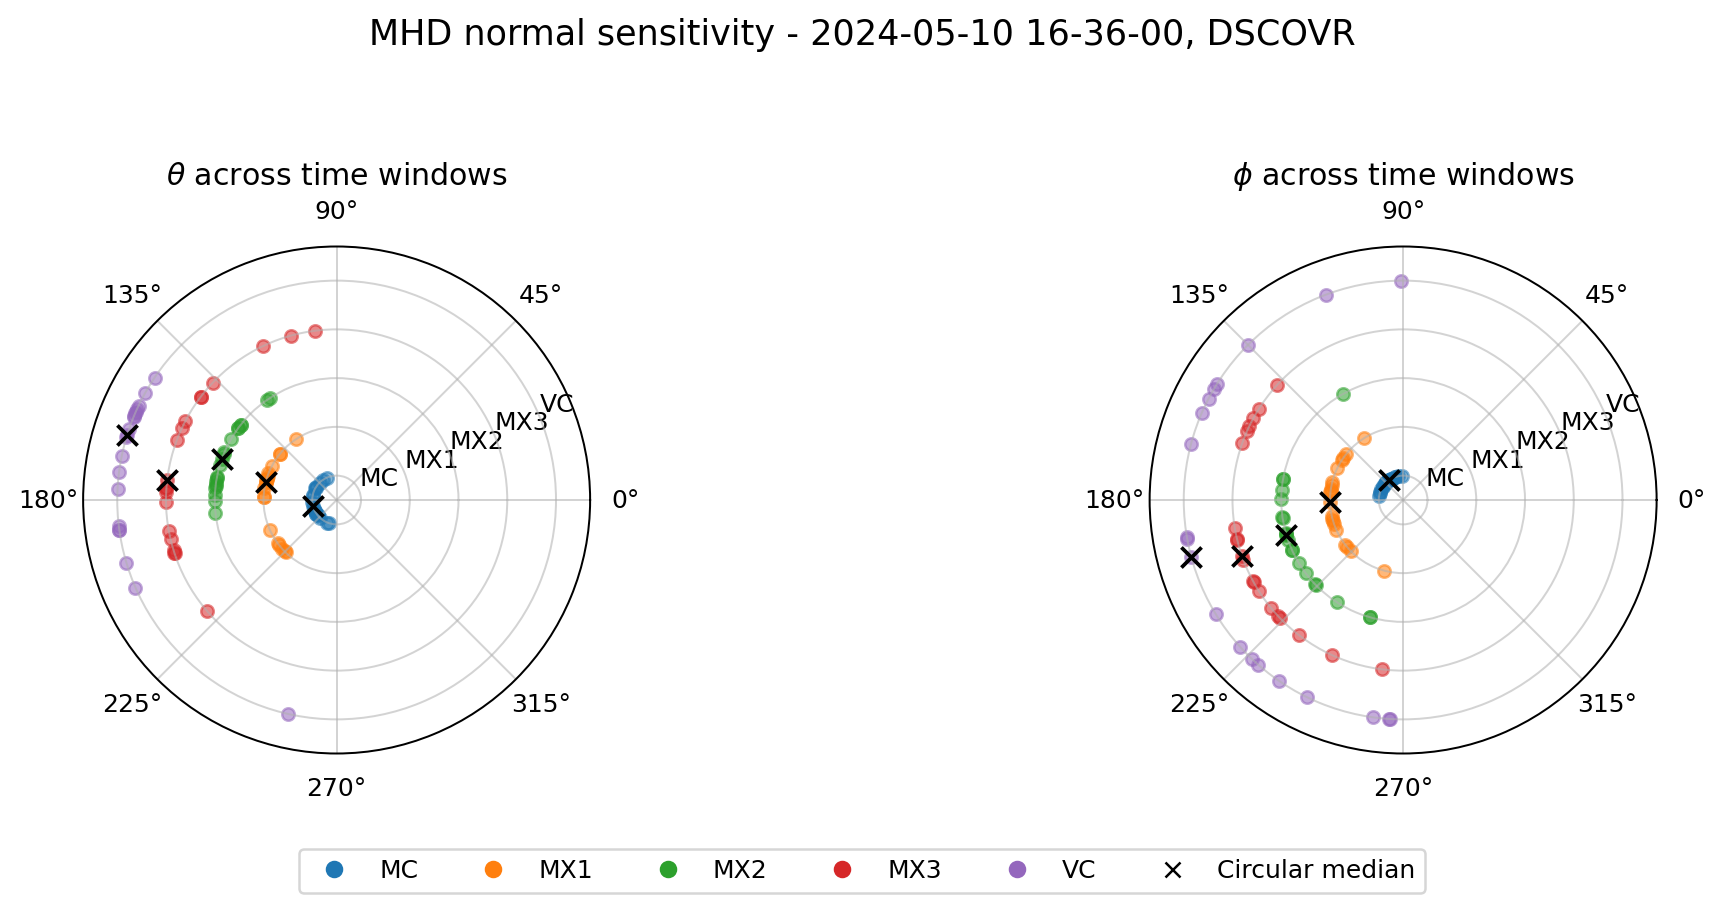

In [85]:
# Plot: theta and phi clouds, one radial ring per MHD method
fig, axes = plt.subplots(ncols=2, figsize=(12, 5), subplot_kw={"projection": "polar"})
method_colors = {method: f"C{index}" for index, method in enumerate(MHD_METHODS)}
method_radii = {method: index + 1 for index, method in enumerate(MHD_METHODS)}

for method in MHD_METHODS:
    method_results = mhd_results.loc[mhd_results["method"] == method]
    radius = method_radii[method]
    color = method_colors[method]
    axes[0].scatter(np.radians(method_results["theta_deg"]), np.full(len(method_results), radius), color=color, alpha=0.55, s=25)
    axes[1].scatter(np.radians(method_results["phi_deg"]), np.full(len(method_results), radius), color=color, alpha=0.55, s=25)
    axes[0].scatter(np.radians(mhd_stats.loc[method, "theta_median_deg"]), radius, marker="x", color="black", s=65, linewidths=1.5, zorder=4)
    axes[1].scatter(np.radians(mhd_stats.loc[method, "phi_median_deg"]), radius, marker="x", color="black", s=65, linewidths=1.5, zorder=4)

for axis, title in zip(axes, (r"$\theta$ across time windows", r"$\phi$ across time windows")):
    axis.set_title(title)
    axis.set_ylim(0.5, len(MHD_METHODS) + 0.7)
    axis.set_yticks(list(method_radii.values()))
    axis.set_yticklabels(MHD_METHODS)
    axis.grid(alpha=0.55)

fig.legend(handles=[Line2D([0], [0], marker="o", linestyle="", color=method_colors[method], label=method) for method in MHD_METHODS] + [Line2D([0], [0], marker="x", linestyle="", color="black", label="Circular median")], loc="lower center", ncol=6)
fig.suptitle(f"MHD normal sensitivity - {EVENT}, {satellite_label(mhd_satellite)}", fontsize=14)
fig.tight_layout(rect=(0, 0.08, 1, 0.92))
plt.show()


## 4. Multi-satellite magnetic and plasma overview

Each satellite gets one row, with magnetic-field magnitude on the left axis and plasma-speed magnitude on the right axis.


In [80]:
# Data prep: per-satellite time windows and magnitude series
EVENT = EVENT_PICKER.value
overview_frames, overview_params, _, overview_satellites = load_event(EVENT)
overview_data = {}

for satellite in overview_satellites:
    frame = overview_frames[satellite]
    t0 = event_time_for_frame(overview_params[satellite]["t0"], frame)
    frame_window = frame.loc[t0 - OVERVIEW_HALF_WINDOW:t0 + OVERVIEW_HALF_WINDOW]
    assert not frame_window.empty, f"No overview data for {satellite} at {EVENT}"

    cadence = frame_window.index.to_series().diff().dropna()
    if not cadence.empty and cadence.min() < pd.Timedelta(seconds=1):
        frame_window = frame_window.resample("1s").mean(numeric_only=True).dropna(how="all")

    overview_data[satellite] = {
        "frame": frame_window,
        "t0": t0,
        "params": overview_params[satellite],
        "magnetic": field_magnitude(frame_window, "B"),
        "plasma_speed": field_magnitude(frame_window, "V"),
    }

overview_summary = pd.DataFrame([{"satellite": satellite_label(satellite), "samples": len(values["frame"]), "has_|B|": values["magnetic"] is not None, "has_|V|": values["plasma_speed"] is not None} for satellite, values in overview_data.items()])
assert not overview_summary.empty, f"No overview satellites for {EVENT}"
display(overview_summary)


,satellite,samples,has_|B|,has_|V|
0,ACE,4801,True,True
1,DSCOVR,4799,True,True
2,MMS1,4800,True,True
3,THEMIS-B,1116,True,False
4,Wind,1594,True,True


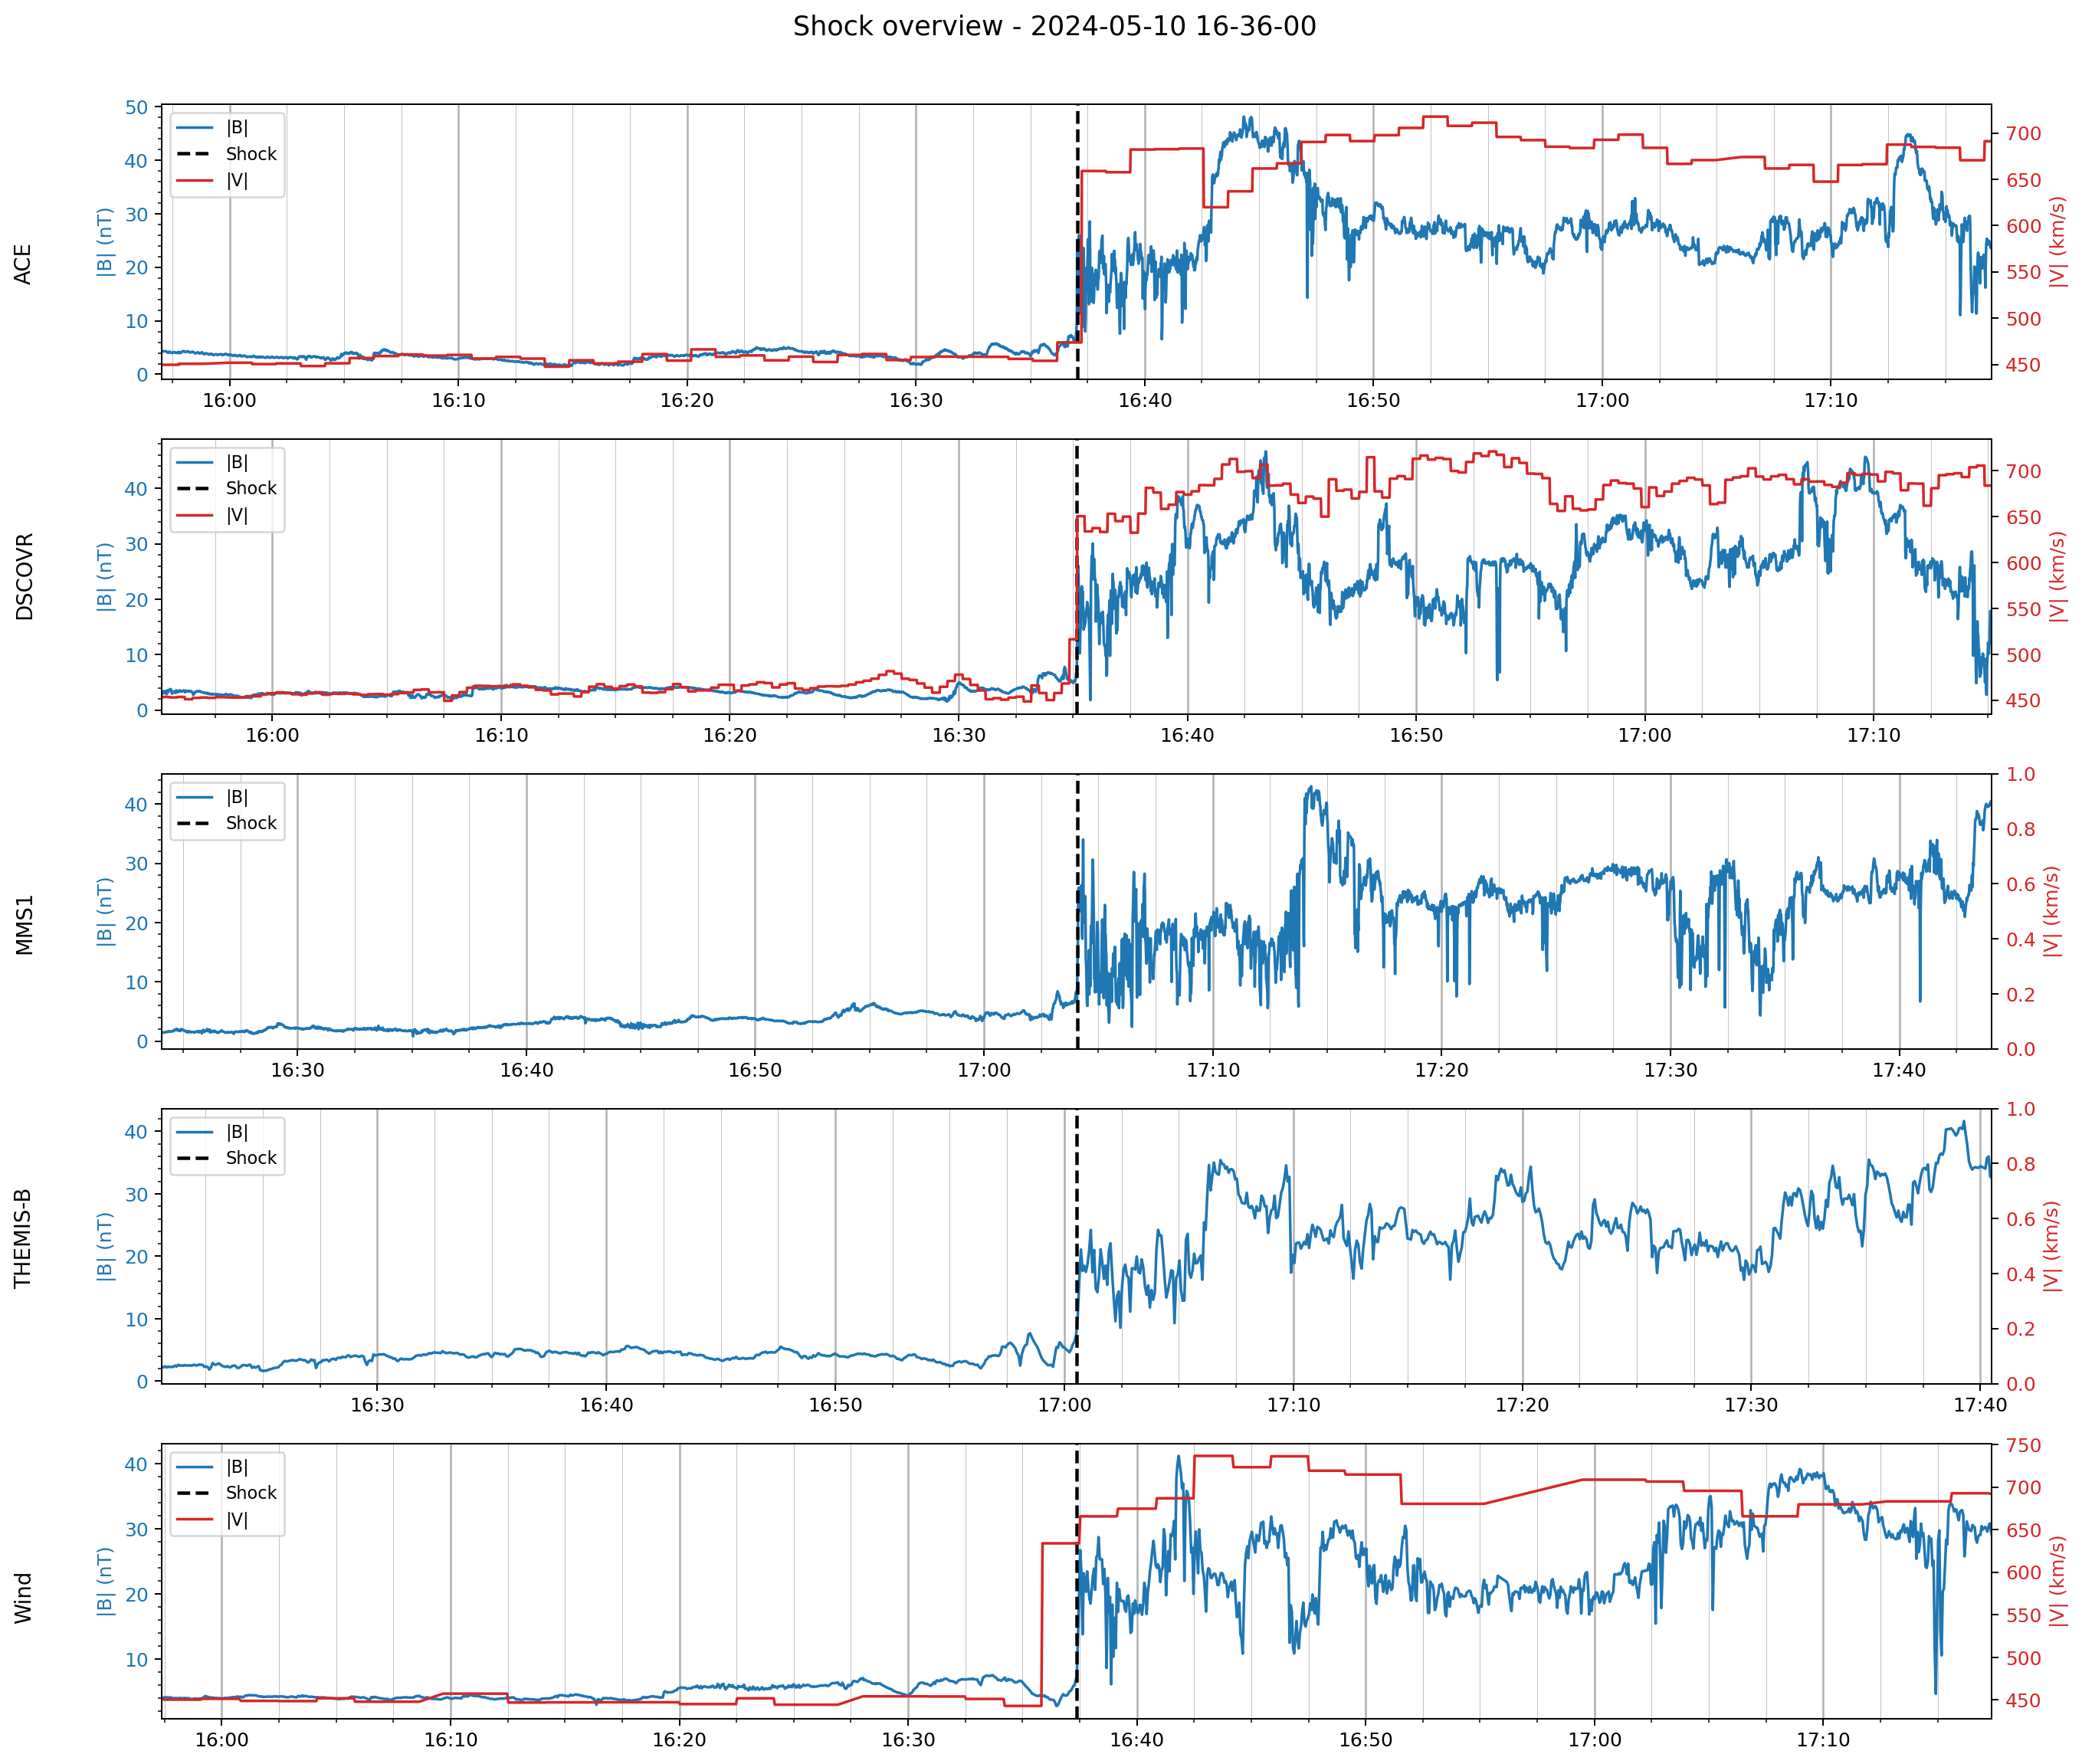

In [81]:
# Plot: one row per satellite, |B| on the left and |V| on the right
fig, axes = plt.subplots(nrows=len(overview_data), figsize=(15, 2.6 * len(overview_data)), sharex=False)
if len(overview_data) == 1:
    axes = [axes]

for axis, (satellite, values) in zip(axes, overview_data.items()):
    frame = values["frame"]
    t0 = values["t0"]
    params = values["params"]
    magnetic = values["magnetic"]
    plasma_speed = values["plasma_speed"]

    if magnetic is not None:
        magnetic = magnetic.dropna()
        if not magnetic.empty:
            axis.plot(magnetic.index, magnetic, "-", color="tab:blue", linewidth=OVERVIEW_LINEWIDTH, label="|B|")
    axis.set_ylabel("|B| (nT)", color="tab:blue")
    axis.tick_params(axis="y", labelcolor="tab:blue")

    plasma_axis = axis.twinx()
    if plasma_speed is not None:
        plasma_speed = plasma_speed.dropna()
        if not plasma_speed.empty:
            plasma_axis.plot(plasma_speed.index, plasma_speed, "-", color="tab:red", linewidth=OVERVIEW_LINEWIDTH, label="|V|")
    plasma_axis.set_ylabel("|V| (km/s)", color="tab:red")
    plasma_axis.tick_params(axis="y", labelcolor="tab:red")

    axis.axvline(t0, color="black", linewidth=1.8, linestyle="--", label="Shock")
    # Upstream/downstream averaging-window boundaries are temporarily disabled.
    # for offset, color in ((params["dt0_u"], "tab:red"), (params["dt1_u"], "tab:orange"), (params["dt0_d"], "tab:blue"), (params["dt1_d"], "tab:purple")):
    #     axis.axvline(t0 + pd.Timedelta(minutes=int(offset)), color=color, linewidth=1.1, linestyle=":", alpha=0.9, label="_nolegend_")

    axis.set_xlim(frame.index[0], frame.index[-1])
    axis.set_title(satellite_label(satellite), rotation="vertical", x=-0.075, y=0.32, fontsize=11)
    handles_left, labels_left = axis.get_legend_handles_labels()
    handles_right, labels_right = plasma_axis.get_legend_handles_labels()
    axis.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left", fontsize=9)
    axis.minorticks_on()
    locator = mdates.MinuteLocator(byminute=range(0, 60, 10))
    axis.xaxis.set_major_locator(locator)
    formatter = mdates.ConciseDateFormatter(locator)
    formatter.offset_formats = [""] * 6
    axis.xaxis.set_major_formatter(formatter)
    axis.grid(visible=True, which="major", axis="x", linewidth=1.0)
    axis.grid(visible=True, which="minor", axis="x", linewidth=0.3)

fig.suptitle(f"Shock overview - {EVENT}", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
